# Credit Default — Modeling

Binary classification: predict whether an **existing** credit card customer defaults next month. These are customers with six months of history — this is risk scoring for review, not an approval screen for new applicants.

Protocol: stratified 60/20/20 train/validation/test split. Model and threshold are selected on **validation** only, frozen, then evaluated **once** on the held-out test set.

In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
from preprocessing import FEATURE_COLUMNS, TARGET

df = pd.read_csv("../data/credit_default_clean.csv")
print(df.shape)
print("default rate:", round(df[TARGET].mean(), 4))

(30000, 24)
default rate: 0.2212


## Stratified train/validation/test split

60% train, 20% validation, 20% test. Stratification keeps the 22.1% default rate identical across splits.

In [2]:
from sklearn.model_selection import train_test_split

X, y = df[FEATURE_COLUMNS], df[TARGET]
X_train, X_rest, y_train, y_rest = train_test_split(
    X, y, test_size=0.40, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_rest, y_rest, test_size=0.50, random_state=42, stratify=y_rest)
for name, yy in [("train", y_train), ("validation", y_val), ("test", y_test)]:
    print(f"{name:>10}: n={len(yy):>6}  default rate={yy.mean():.4f}")

     train: n= 18000  default rate=0.2212
validation: n=  6000  default rate=0.2212
      test: n=  6000  default rate=0.2212


## Baseline

Predicting "no default" for everyone scores the majority share. Accuracy provides a reference, but the operating threshold is selected for illustrative misclassification cost. Compare performance against the baseline on that objective as well. (Reported on the test set; the baseline involves no selection.)

In [3]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

baseline = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
base_acc = accuracy_score(y_test, baseline.predict(X_test))
print(f"majority-class baseline accuracy (test): {base_acc:.4f}")

majority-class baseline accuracy (test): 0.7788


## Candidate models

- Logistic Regression inside a `StandardScaler` pipeline (scaling fit on train only).
- HistGradientBoosting (handles the skewed bill/payment amounts natively).

Both fit on train. Compared on **validation** at the default 0.5 threshold first.

In [4]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

logreg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
hgb = HistGradientBoostingClassifier(random_state=42)

for name, model in [("logreg", logreg), ("hgb", hgb)]:
    model.fit(X_train, y_train)
    print(f"{name}: val acc={accuracy_score(y_val, model.predict(X_val)):.4f} "
          f"val ROC-AUC={roc_auc_score(y_val, model.predict_proba(X_val)[:, 1]):.4f}")

logreg: val acc=0.8028 val ROC-AUC=0.7030


hgb: val acc=0.8135 val ROC-AUC=0.7719


## Calibration check (validation set)

A review flag needs probabilities that mean what they say, not just good rankings. Brier score plus a reliability curve with **per-bin sample sizes** — a curve without counts can hide that the interesting bins are nearly empty.

This is an evaluation of the fitted models, not a selection step: no post-hoc calibration is applied here.

--- Logistic Regression: per-bin n / mean predicted / observed rate ---
      bin    n  mean_predicted  observed_rate
[0.0,0.1) 1116          0.0622         0.1308
[0.1,0.2) 2124          0.1510         0.1365
[0.2,0.3) 1708          0.2363         0.1827
[0.3,0.4)  289          0.3460         0.3460
[0.4,0.5)  311          0.4494         0.5820
[0.5,0.6)  225          0.5467         0.5867
[0.6,0.7)  138          0.6409         0.7464
[0.7,0.8)   44          0.7442         0.7500
[0.8,0.9)   35          0.8455         0.7143
[0.9,1.0)   10          0.9408         0.5000

--- HistGradientBoosting: per-bin n / mean predicted / observed rate ---
      bin    n  mean_predicted  observed_rate
[0.0,0.1) 1779          0.0679         0.0658
[0.1,0.2) 2245          0.1466         0.1599
[0.2,0.3)  730          0.2407         0.2425
[0.3,0.4)  389          0.3430         0.3779
[0.4,0.5)  189          0.4444         0.4709
[0.5,0.6)  121          0.5566         0.5455
[0.6,0.7)  233          0.

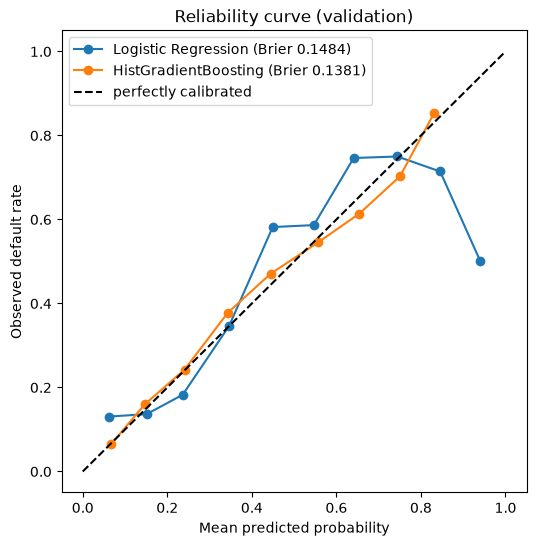

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

fig, ax = plt.subplots(figsize=(6, 6))
for name, model in [("Logistic Regression", logreg), ("HistGradientBoosting", hgb)]:
    pr = model.predict_proba(X_val)[:, 1]
    brier = brier_score_loss(y_val, pr)
    frac_pos, mean_pred = calibration_curve(y_val, pr, n_bins=10)
    counts, _ = np.histogram(pr, bins=10, range=(0, 1))
    ax.plot(mean_pred, frac_pos, marker="o", label=f"{name} (Brier {brier:.4f})")
    print(f"--- {name}: per-bin n / mean predicted / observed rate ---")
    print(pd.DataFrame({
        "bin": [f"[{i/10:.1f},{(i+1)/10:.1f})" for i in range(10)],
        "n": counts,
        "mean_predicted": np.round(
            [pr[(pr >= i/10) & (pr < (i+1)/10)].mean() if c else np.nan
             for i, c in enumerate(counts)], 4),
        "observed_rate": np.round(
            [y_val[(pr >= i/10) & (pr < (i+1)/10)].mean() if c else np.nan
             for i, c in enumerate(counts)], 4),
    }).to_string(index=False))
    print()
ax.plot([0, 1], [0, 1], "k--", label="perfectly calibrated")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed default rate")
ax.set_title("Reliability curve (validation)")
ax.legend()
plt.show()

## Model + threshold selection (validation only)

**Cost assumption** (illustrative, not a business fact): a missed defaulter (false negative) costs 5x a false alarm on a good customer (false positive), i.e. `cost = 5*FN + 1*FP`.

For each candidate: scan thresholds 0.10–0.90 in 0.05 steps on **validation**, take the cost-minimizing threshold (ties go to the lower threshold). The candidate with the lowest validation cost wins. The test set is not touched in this cell.

In [6]:
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score

FN_COST, FP_COST = 5, 1
GRID = [round(float(t), 2) for t in np.arange(0.10, 0.91, 0.05)]

def cost_at(yt, proba, t):
    tn, fp, fn, tp = confusion_matrix(yt, (proba >= t).astype(int)).ravel()
    return FN_COST * fn + FP_COST * fp

costs = {}
for name, model in [("logreg", logreg), ("hgb", hgb)]:
    pv = model.predict_proba(X_val)[:, 1]
    costs[name] = {t: cost_at(y_val, pv, t) for t in GRID}

print(f"{'threshold':>9} {'logreg cost':>11} {'hgb cost':>9}")
for t in GRID:
    print(f"{t:>9.2f} {costs['logreg'][t]:>11,} {costs['hgb'][t]:>9,}")

val_choice = {}
for name in ["logreg", "hgb"]:
    t_best = min(GRID, key=lambda t: costs[name][t])
    val_choice[name] = (t_best, costs[name][t_best])
    print(f"{name}: best validation threshold {t_best:.2f} (cost {val_choice[name][1]:,})")

selected = min(val_choice, key=lambda n: val_choice[n][1])
threshold, val_cost = val_choice[selected]
print(f"\nselected on validation: {selected} @ {threshold:.2f}")

threshold logreg cost  hgb cost
     0.10       4,433     3,596
     0.15       4,304     3,426
     0.20       4,049     3,505
     0.25       3,909     3,638
     0.30       4,213     3,837
     0.35       4,354     4,104
     0.40       4,524     4,330
     0.45       4,865     4,565
     0.50       5,299     4,675
     0.55       5,542     4,792
     0.60       5,866     4,950
     0.65       6,197     5,192
     0.70       6,346     5,575
     0.75       6,423     5,937
     0.80       6,500     6,408
     0.85       6,571     6,561
     0.90       6,615     6,635
logreg: best validation threshold 0.25 (cost 3,909)
hgb: best validation threshold 0.15 (cost 3,426)

selected on validation: hgb @ 0.15


## Final evaluation: frozen model, held-out test set (once)

The model and threshold are fixed before this evaluation. Test results are reported here; they are not used to choose the model or threshold.

In [7]:
from sklearn.metrics import classification_report

final_model = {"logreg": logreg, "hgb": hgb}[selected]
proba_test = final_model.predict_proba(X_test)[:, 1]
p_test = (proba_test >= threshold).astype(int)

print(f"model={selected}  frozen threshold={threshold:.2f}  test n={len(y_test)}")
print(f"accuracy={accuracy_score(y_test, p_test):.4f}  "
      f"precision={precision_score(y_test, p_test):.4f}  "
      f"recall={recall_score(y_test, p_test):.4f}  "
      f"f1={f1_score(y_test, p_test):.4f}  "
      f"roc_auc={roc_auc_score(y_test, proba_test):.4f}")
print(f"baseline accuracy={base_acc:.4f}")
print()
print("confusion matrix [tn, fp / fn, tp]:")
print(confusion_matrix(y_test, p_test))
print()
print(classification_report(y_test, p_test, digits=3))

model_cost = cost_at(y_test, proba_test, threshold)
baseline_pred = baseline.predict(X_test)
_, baseline_fp, baseline_fn, _ = confusion_matrix(y_test, baseline_pred).ravel()
baseline_cost = FN_COST * baseline_fn + FP_COST * baseline_fp
print(f"Illustrative test cost (5*FN + FP): model={model_cost:,}, baseline={baseline_cost:,}")
print(f"Cost reduction vs baseline: {(baseline_cost - model_cost) / baseline_cost:.1%}")

model=hgb  frozen threshold=0.15  test n=6000
accuracy=0.6328  precision=0.3532  recall=0.7943  f1=0.4890  roc_auc=0.7858
baseline accuracy=0.7788

confusion matrix [tn, fp / fn, tp]:
[[2743 1930]
 [ 273 1054]]

              precision    recall  f1-score   support

           0      0.909     0.587     0.713      4673
           1      0.353     0.794     0.489      1327

    accuracy                          0.633      6000
   macro avg      0.631     0.691     0.601      6000
weighted avg      0.786     0.633     0.664      6000



Illustrative test cost (5*FN + FP): model=3,295, baseline=6,635
Cost reduction vs baseline: 50.3%


## Save artifacts

`src/train.py` reproduces exactly this pipeline from the cleaned CSV, so the API never depends on the notebooks. Saving here too, for inspection.

In [8]:
import json
import joblib

joblib.dump(final_model, "../models/model.joblib")
meta = {
    "model": f"{type(final_model).__name__} (selected on validation)",
    "features": FEATURE_COLUMNS,
    "split": "stratified 60/20/20 train/validation/test, random_state=42",
    "threshold": float(threshold),
    "threshold_selection": (
        f"grid 0.10-0.90 step 0.05, cost = {FN_COST}*FN + {FP_COST}*FP, "
        f"minimized on VALIDATION only (selected cost {val_cost:,}); "
        "test set evaluated once afterwards"
    ),
    "threshold_cost_assumption": (
        "illustrative assumption: a missed defaulter costs 5x a false alarm "
        "on a good customer; not an observed business fact"
    ),
    "test_metrics_at_frozen_threshold": {
        "accuracy": round(float(accuracy_score(y_test, p_test)), 4),
        "precision": round(float(precision_score(y_test, p_test)), 4),
        "recall": round(float(recall_score(y_test, p_test)), 4),
        "f1": round(float(f1_score(y_test, p_test)), 4),
        "roc_auc": round(float(roc_auc_score(y_test, proba_test)), 4),
        "baseline_accuracy": round(float(base_acc), 4),
    },
    "data": ("UCI default of credit card clients (Taiwan); 30000 rows; "
             "existing card customers with 6 months of history; no timestamps "
             "(no out-of-time evaluation)"),
}
with open("../models/metadata.json", "w") as f:
    json.dump(meta, f, indent=2)
print("saved ../models/model.joblib + ../models/metadata.json")

saved ../models/model.joblib + ../models/metadata.json


## Findings and limitations

- Validation selects a threshold of 0.15 from the 0.10–0.90 grid. It has the lowest validation cost among the thresholds tested; a finer search could select a different value.
- `decision = 1` is a **flag for review**, a risk signal on existing customers — not a rejection of an applicant.
- Limitations: single split (no cross-validation); the 5:1 cost ratio is an illustrative assumption; Taiwan-2005 data; no timestamps, so no out-of-time evaluation; reliability of the probabilities outside this sample is not established.